# Module 1 — Détection des polymères par TGA-FTIR avec XGBoost

Ce notebook remplace le 1D-CNN instable par un modèle **XGBoost** plus adapté au faible nombre d'expériences indépendantes.

## Pourquoi cette correction ?

- Le 1D-CNN donnait de très bonnes performances sur le pli 1, mais échouait fortement sur le pli 2.
- Les courbes de validation étaient trop optimistes, car les lignes d'un même fichier pouvaient être très proches.
- XGBoost est utilisé ici avec une normalisation spectrale SNV et une séparation stricte par fichier.

## Sortie du modèle

- `0` : cellulose / non-plastique
- `1` : polymère / plastique

> Limite importante : seulement deux fichiers non plastiques indépendants sont disponibles. Le résultat reste une preuve de concept.

In [1]:
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.utils.class_weight import compute_sample_weight

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "XGBoost n'est pas installé. Exécute dans le terminal : pip install xgboost"
    ) from exc

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

cwd = Path.cwd()
if (cwd / 'data').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'data').exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Impossible de trouver le dossier data.")

DATASET_PATH = PROJECT_ROOT / 'data' / 'processed' / 'module1_spectra_binary.npz'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'module1' / 'xgboost'
MODELS_DIR = PROJECT_ROOT / 'models' / 'module1'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print('Dataset :', DATASET_PATH)
print('Dataset trouvé :', DATASET_PATH.exists())
assert DATASET_PATH.exists(), f'Dataset introuvable : {DATASET_PATH}'

Dataset : C:\Users\elasr\OneDrive\Desktop\hind\data\processed\module1_spectra_binary.npz
Dataset trouvé : True


## 1. Chargement et normalisation SNV

La normalisation SNV est appliquée séparément à chaque spectre :

$$x_{SNV}=\frac{x-\bar{x}}{s_x}$$

Elle réduit les différences d'échelle et les effets de ligne de base entre les expériences.

In [2]:
data = np.load(DATASET_PATH, allow_pickle=True)

X_raw = data['X'].astype(np.float32)
y = data['y'].astype(np.int32)
groups = data['groups'].astype(str)
families = data['families'].astype(str)
wavenumbers = data['wavenumbers'].astype(np.float32)

def snv_transform(X: np.ndarray) -> np.ndarray:
    means = X.mean(axis=1, keepdims=True)
    stds = X.std(axis=1, keepdims=True)
    return ((X - means) / (stds + 1e-8)).astype(np.float32)

X = snv_transform(X_raw)

print('Dimensions :', X.shape)
print('Fichiers indépendants :', len(np.unique(groups)))
print('Polymères :', int((y == 1).sum()))
print('Non-plastiques :', int((y == 0).sum()))
print('Fichiers cellulose :', np.unique(groups[y == 0]).tolist())
print('Valeurs non finies :', int((~np.isfinite(X)).sum()))

assert np.isfinite(X).all()
assert len(np.unique(groups[y == 0])) == 2

Dimensions : (7544, 415)
Fichiers indépendants : 29
Polymères : 7022
Non-plastiques : 522
Fichiers cellulose : ['DF_20231109 cellulose NRC 150-750C.csv', 'DF_20231110 cellulose sigma 150-750C.csv']
Valeurs non finies : 0


## 2. Deux plis totalement séparés par fichier

Chaque fichier n'apparaît que dans l'entraînement ou dans le test, jamais dans les deux.

In [3]:
negative_groups = sorted(np.unique(groups[y == 0]).tolist())
positive_groups = sorted(np.unique(groups[y == 1]).tolist())

rng = np.random.default_rng(SEED)
positive_groups_shuffled = positive_groups.copy()
rng.shuffle(positive_groups_shuffled)
positive_halves = np.array_split(positive_groups_shuffled, 2)

folds = []
for fold_index in range(2):
    test_groups = set(
        positive_halves[fold_index].tolist() + [negative_groups[fold_index]]
    )
    train_groups = set(np.unique(groups).tolist()) - test_groups

    train_idx = np.where(np.isin(groups, list(train_groups)))[0]
    test_idx = np.where(np.isin(groups, list(test_groups)))[0]

    assert set(groups[train_idx]).isdisjoint(set(groups[test_idx]))
    assert set(np.unique(y[train_idx])) == {0, 1}
    assert set(np.unique(y[test_idx])) == {0, 1}

    folds.append((train_idx, test_idx, train_groups, test_groups))

    print(f'Pli {fold_index + 1}')
    print('  Fichiers train :', len(train_groups))
    print('  Fichiers test  :', len(test_groups))
    print('  Lignes train   :', len(train_idx))
    print('  Lignes test    :', len(test_idx))
    print('  Cellulose test :', negative_groups[fold_index])
    print()

Pli 1
  Fichiers train : 14
  Fichiers test  : 15
  Lignes train   : 3640
  Lignes test    : 3904
  Cellulose test : DF_20231109 cellulose NRC 150-750C.csv

Pli 2
  Fichiers train : 15
  Fichiers test  : 14
  Lignes train   : 3904
  Lignes test    : 3640
  Cellulose test : DF_20231110 cellulose sigma 150-750C.csv



## 3. Entraînement XGBoost

Les poids équilibrés compensent le faible nombre d'observations non plastiques.


PLI 1

Métriques par ligne :
fold                  : 1
accuracy              : 0.9633709016393442
balanced_accuracy     : 0.8683303832574517
precision             : 0.9826254826254827
recall                : 0.978040076859731
f1                    : 0.9803274178016234
roc_auc               : 0.9430987681198288
test_files            : 15
test_rows             : 3904

Métriques par fichier :
fold                  : 1
file_accuracy         : 1.0
file_balanced_accuracy: 1.0
file_f1               : 1.0
n_test_files          : 15

Rapport de classification par ligne :
               precision    recall  f1-score   support

Non-plastique     0.7122    0.7586    0.7347       261
     Polymère     0.9826    0.9780    0.9803      3643

     accuracy                         0.9634      3904
    macro avg     0.8474    0.8683    0.8575      3904
 weighted avg     0.9645    0.9634    0.9639      3904



,fold,group,family,true_label,mean_probability,median_probability,n_rows,predicted_label
6,1,DF_20231109 cellulose NRC 150-750C.csv,CELLULOSE,0,0.271284,0.006880,261,0
12,1,DF_20240116 PA 6 Magerial 150-750C.csv,PA,1,0.790051,0.988767,261,1
10,1,DF_20240115 PC Magerial 150-750C.csv,PC,1,0.909380,0.985901,261,1
7,1,DF_20240109 PET Sigma 150-750C.csv,PET,1,0.915826,0.988121,261,1
14,1,DF_20240308 PP NC 150-750C.csv,PP,1,0.944851,0.988994,253,1
0,1,DF_20230821 LDPE industrial 150-750C.csv,PE,1,0.957778,0.999375,260,1
11,1,DF_20240115 PVC Magerial 150-750C.csv,PVC,1,0.985609,0.999558,261,1
13,1,DF_20240116 PA 66 Magerial 150-750C.csv,PA,1,0.986523,0.997918,260,1
5,1,DF_20231108 Nylon Flock 150-750C.csv,PA,1,0.992603,0.999365,260,1
8,1,DF_20240110 HDPE Sigma 150-750C.csv,PE,1,0.993997,0.997039,261,1


<Figure size 600x500 with 0 Axes>

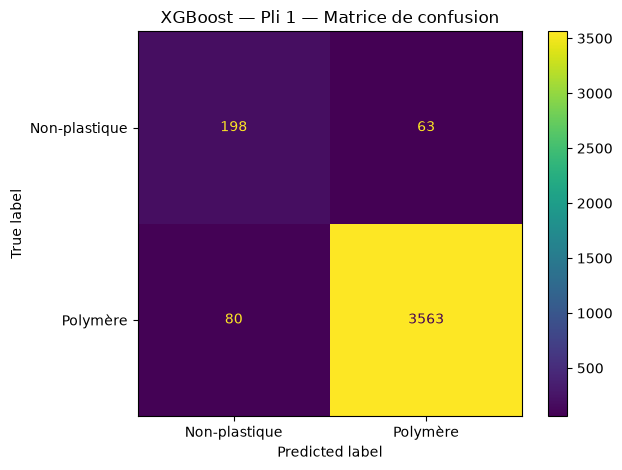

<Figure size 600x500 with 0 Axes>

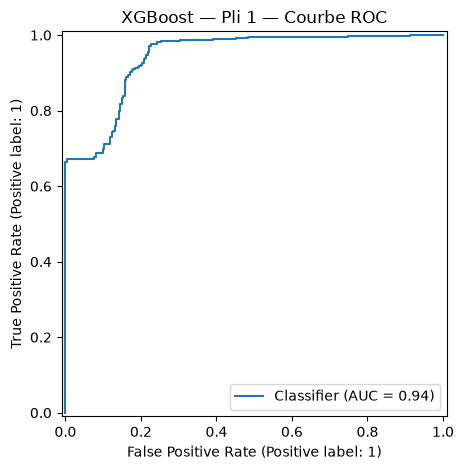


PLI 2

Métriques par ligne :
fold                  : 2
accuracy              : 0.9741758241758242
balanced_accuracy     : 0.8570458284717757
precision             : 0.9787234042553191
recall                : 0.9937851435335898
f1                    : 0.9861967694566813
roc_auc               : 0.9196332089454927
test_files            : 14
test_rows             : 3640

Métriques par fichier :
fold                  : 2
file_accuracy         : 1.0
file_balanced_accuracy: 1.0
file_f1               : 1.0
n_test_files          : 14

Rapport de classification par ligne :
               precision    recall  f1-score   support

Non-plastique     0.8995    0.7203    0.8000       261
     Polymère     0.9787    0.9938    0.9862      3379

     accuracy                         0.9742      3640
    macro avg     0.9391    0.8570    0.8931      3640
 weighted avg     0.9730    0.9742    0.9728      3640



,fold,group,family,true_label,mean_probability,median_probability,n_rows,predicted_label
8,2,DF_20231110 cellulose sigma 150-750C.csv,CELLULOSE,0,0.307079,0.014585,261,0
10,2,DF_20240115 PVC Sigma 150-750C.csv,PVC,1,0.913369,0.999589,261,1
13,2,DF_20240308 PC NC 150-750C.csv,PC,1,0.950911,0.996231,253,1
11,2,DF_20240116 PMMA Magerial 150-750C.csv,PMMA,1,0.998165,0.999373,261,1
2,2,DF_20230818 PET industrial 150-750C.csv,PET,1,0.999026,0.999789,260,1
9,2,DF_20240109 PET Flock 150-750C.csv,PET,1,0.999327,0.999467,260,1
5,2,DF_20231108 PS Cospheric 150-750C.csv,PS,1,0.999498,0.999645,260,1
0,2,DF_20230817 PE 20um 150-750C.csv,PE,1,0.999644,0.999759,260,1
12,2,DF_20240117 PMMA Sigma 150-750C.csv,PMMA,1,0.999653,0.999691,261,1
4,2,DF_20230823 PVC industrial 150-750C.csv,PVC,1,0.999694,0.999798,260,1


<Figure size 600x500 with 0 Axes>

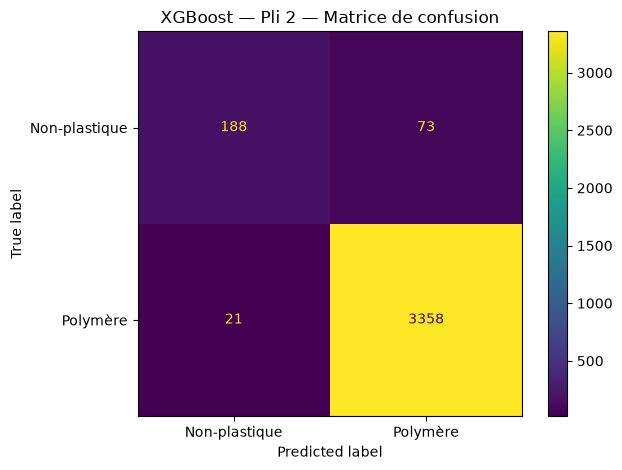

<Figure size 600x500 with 0 Axes>

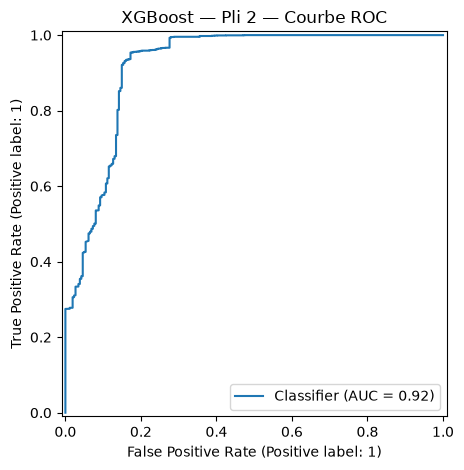


✅ Évaluation terminée.


In [4]:
def build_xgboost_model() -> XGBClassifier:
    return XGBClassifier(
        n_estimators=250,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=1,
        reg_alpha=0.01,
        reg_lambda=1.0,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=SEED,
        n_jobs=4
    )

row_metrics = []
file_metrics = []
all_row_predictions = []
all_file_predictions = []
fold_models = []

for fold_number, (train_idx, test_idx, train_groups, test_groups) in enumerate(folds, start=1):
    print('\n' + '=' * 72)
    print(f'PLI {fold_number}')
    print('=' * 72)

    model = build_xgboost_model()
    sample_weights = compute_sample_weight(class_weight='balanced', y=y[train_idx])

    model.fit(X[train_idx], y[train_idx], sample_weight=sample_weights)
    fold_models.append(model)

    probabilities = model.predict_proba(X[test_idx])[:, 1]
    predictions = (probabilities >= 0.5).astype(np.int32)

    current_row_metrics = {
        'fold': fold_number,
        'accuracy': accuracy_score(y[test_idx], predictions),
        'balanced_accuracy': balanced_accuracy_score(y[test_idx], predictions),
        'precision': precision_score(y[test_idx], predictions, zero_division=0),
        'recall': recall_score(y[test_idx], predictions, zero_division=0),
        'f1': f1_score(y[test_idx], predictions, zero_division=0),
        'roc_auc': roc_auc_score(y[test_idx], probabilities),
        'test_files': len(test_groups),
        'test_rows': len(test_idx)
    }
    row_metrics.append(current_row_metrics)

    row_predictions = pd.DataFrame({
        'fold': fold_number,
        'group': groups[test_idx],
        'family': families[test_idx],
        'true_label': y[test_idx],
        'probability_polymer': probabilities,
        'predicted_label': predictions
    })
    all_row_predictions.append(row_predictions)

    # La décision finale réelle est calculée par fichier expérimental.
    file_predictions = (
        row_predictions
        .groupby(['fold', 'group', 'family', 'true_label'], as_index=False)
        .agg(
            mean_probability=('probability_polymer', 'mean'),
            median_probability=('probability_polymer', 'median'),
            n_rows=('probability_polymer', 'size')
        )
    )
    file_predictions['predicted_label'] = (
        file_predictions['mean_probability'] >= 0.5
    ).astype(np.int32)
    all_file_predictions.append(file_predictions)

    current_file_metrics = {
        'fold': fold_number,
        'file_accuracy': accuracy_score(
            file_predictions['true_label'], file_predictions['predicted_label']
        ),
        'file_balanced_accuracy': balanced_accuracy_score(
            file_predictions['true_label'], file_predictions['predicted_label']
        ),
        'file_f1': f1_score(
            file_predictions['true_label'], file_predictions['predicted_label'],
            zero_division=0
        ),
        'n_test_files': len(file_predictions)
    }
    file_metrics.append(current_file_metrics)

    print('\nMétriques par ligne :')
    for key, value in current_row_metrics.items():
        print(f'{key:22s}: {value}')

    print('\nMétriques par fichier :')
    for key, value in current_file_metrics.items():
        print(f'{key:22s}: {value}')

    print('\nRapport de classification par ligne :')
    print(classification_report(
        y[test_idx], predictions,
        target_names=['Non-plastique', 'Polymère'],
        digits=4,
        zero_division=0
    ))

    display(file_predictions.sort_values('mean_probability'))

    plt.figure(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y[test_idx], predictions,
        display_labels=['Non-plastique', 'Polymère'],
        values_format='d'
    )
    plt.title(f'XGBoost — Pli {fold_number} — Matrice de confusion')
    plt.tight_layout()
    plt.savefig(
        RESULTS_DIR / f'fold_{fold_number}_confusion_matrix.png',
        dpi=160, bbox_inches='tight'
    )
    plt.show()

    plt.figure(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y[test_idx], probabilities)
    plt.title(f'XGBoost — Pli {fold_number} — Courbe ROC')
    plt.tight_layout()
    plt.savefig(
        RESULTS_DIR / f'fold_{fold_number}_roc.png',
        dpi=160, bbox_inches='tight'
    )
    plt.show()

    joblib.dump(
        model,
        MODELS_DIR / f'module1_xgboost_fold_{fold_number}.joblib'
    )

print('\n✅ Évaluation terminée.')

## 4. Résumé des performances

In [5]:
row_metrics_df = pd.DataFrame(row_metrics)
file_metrics_df = pd.DataFrame(file_metrics)
row_predictions_df = pd.concat(all_row_predictions, ignore_index=True)
file_predictions_df = pd.concat(all_file_predictions, ignore_index=True)

metric_columns = [
    'accuracy', 'balanced_accuracy', 'precision',
    'recall', 'f1', 'roc_auc'
]

row_summary_df = pd.DataFrame({
    'moyenne': row_metrics_df[metric_columns].mean(),
    'ecart_type': row_metrics_df[metric_columns].std(ddof=0)
})

print('Métriques par pli — niveau ligne :')
display(row_metrics_df)

print('Résumé moyen — niveau ligne :')
display(row_summary_df)

print('Métriques par pli — niveau fichier :')
display(file_metrics_df)

row_metrics_df.to_csv(
    RESULTS_DIR / 'metrics_par_pli.csv', index=False, encoding='utf-8-sig'
)
row_summary_df.to_csv(
    RESULTS_DIR / 'metrics_resume.csv', encoding='utf-8-sig'
)
file_metrics_df.to_csv(
    RESULTS_DIR / 'metrics_par_fichier.csv', index=False, encoding='utf-8-sig'
)
row_predictions_df.to_csv(
    RESULTS_DIR / 'predictions_par_ligne.csv', index=False, encoding='utf-8-sig'
)
file_predictions_df.to_csv(
    RESULTS_DIR / 'predictions_par_fichier.csv', index=False, encoding='utf-8-sig'
)

print('✅ Résultats sauvegardés dans :', RESULTS_DIR)

Métriques par pli — niveau ligne :


,fold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,test_files,test_rows
0,1,0.963371,0.868330,0.982625,0.978040,0.980327,0.943099,15,3904
1,2,0.974176,0.857046,0.978723,0.993785,0.986197,0.919633,14,3640


Résumé moyen — niveau ligne :


,moyenne,ecart_type
accuracy,0.968773,0.005402
balanced_accuracy,0.862688,0.005642
precision,0.980674,0.001951
recall,0.985913,0.007873
f1,0.983262,0.002935
roc_auc,0.931366,0.011733


Métriques par pli — niveau fichier :


,fold,file_accuracy,file_balanced_accuracy,file_f1,n_test_files
0,1,1.0,1.0,1.0,15
1,2,1.0,1.0,1.0,14


✅ Résultats sauvegardés dans : C:\Users\elasr\OneDrive\Desktop\hind\results\module1\xgboost


## 5. Entraînement et sauvegarde du modèle final

In [6]:
final_model = build_xgboost_model()
final_sample_weights = compute_sample_weight(class_weight='balanced', y=y)
final_model.fit(X, y, sample_weight=final_sample_weights)

final_model_path = MODELS_DIR / 'module1_xgboost_final.joblib'
metadata_path = MODELS_DIR / 'module1_xgboost_metadata.json'

joblib.dump(final_model, final_model_path)

metadata = {
    'task': 'binary_polymer_detection',
    'algorithm': 'XGBoost',
    'preprocessing': 'SNV per spectrum',
    'negative_class': 'cellulose_non_plastique',
    'positive_class': 'polymer_plastic',
    'threshold': 0.5,
    'aggregation': 'mean probability over all rows of one CSV file',
    'n_features': int(X.shape[1]),
    'wavenumbers': wavenumbers.tolist(),
    'limitation': (
        'Only two independent cellulose files were available. '
        'Results are a proof of concept and require additional non-plastic samples.'
    )
}

metadata_path.write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2),
    encoding='utf-8'
)

print('✅ Modèle final :', final_model_path)
print('✅ Métadonnées :', metadata_path)

✅ Modèle final : C:\Users\elasr\OneDrive\Desktop\hind\models\module1\module1_xgboost_final.joblib
✅ Métadonnées : C:\Users\elasr\OneDrive\Desktop\hind\models\module1\module1_xgboost_metadata.json


## 6. Importance des nombres d'onde

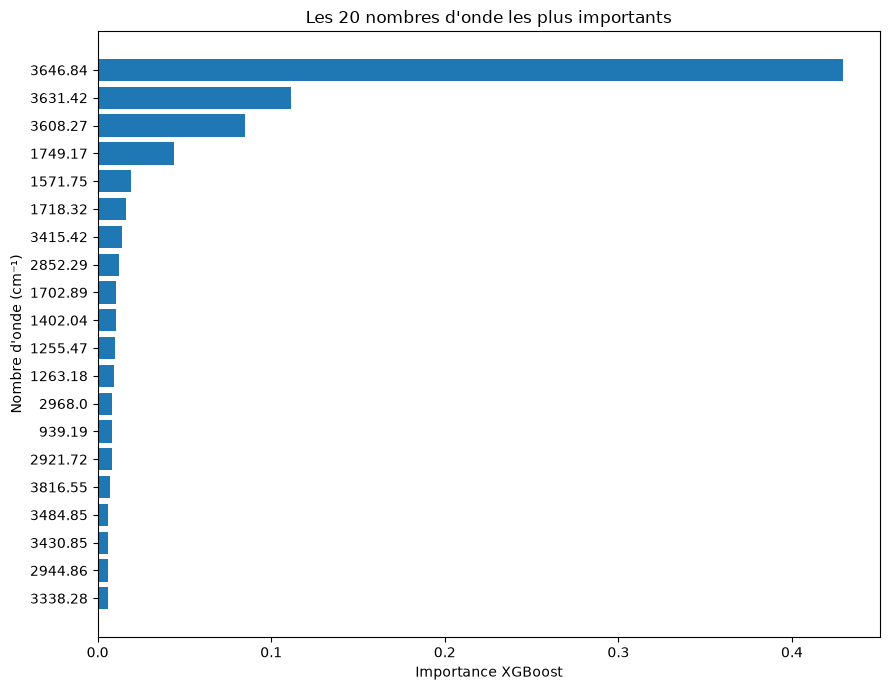

,wavenumber_cm-1,importance
369,3646.843506,0.429256
367,3631.415283,0.111645
364,3608.272949,0.085094
123,1749.173340,0.044230
100,1571.749023,0.019359
119,1718.317017,0.016391
339,3415.420410,0.014118
266,2852.290527,0.012560
117,1702.888794,0.010786
78,1402.038696,0.010506


In [7]:
importance_df = pd.DataFrame({
    'wavenumber_cm-1': wavenumbers,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

top_features = importance_df.head(20).sort_values('importance')

plt.figure(figsize=(9, 7))
plt.barh(
    top_features['wavenumber_cm-1'].round(2).astype(str),
    top_features['importance']
)
plt.title("Les 20 nombres d'onde les plus importants")
plt.xlabel('Importance XGBoost')
plt.ylabel("Nombre d'onde (cm⁻¹)")
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / 'top_20_wavenumbers.png',
    dpi=160, bbox_inches='tight'
)
plt.show()

importance_df.to_csv(
    RESULTS_DIR / 'feature_importance.csv',
    index=False,
    encoding='utf-8-sig'
)

display(importance_df.head(20))

## Fichiers finaux attendus

Dans `models/module1/` :

- `module1_xgboost_final.joblib`
- `module1_xgboost_metadata.json`

Dans `results/module1/xgboost/` :

- métriques par pli ;
- métriques par fichier ;
- matrices de confusion ;
- courbes ROC ;
- importance des nombres d'onde ;
- prédictions par ligne et par fichier.